In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
warnings.filterwarnings('ignore')
print("Pandas loaded successfully! Version:", pd.__version__)

Pandas loaded successfully! Version: 2.3.3


In [2]:
# Load the dataset — single load, reused throughout Part 1
df = pd.read_csv('dailyActivity_merged.csv')
 
# Display the first 5 rows to understand the structure
print("--- FIRST 5 ROWS OF THE DATASET ---")
print(df.head())

--- FIRST 5 ROWS OF THE DATASET ---
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    3/25/2016       11004           7.11             7.11   
1  1503960366    3/26/2016       17609          11.55            11.55   
2  1503960366    3/27/2016       12736           8.53             8.53   
3  1503960366    3/28/2016       13231           8.93             8.93   
4  1503960366    3/29/2016       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryAct

In [3]:
# Check data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [4]:
# Save the table into a variable called df
df = pd.read_csv('dailyActivity_merged.csv')

# Check data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [5]:
# Convert ActivityDate from object (text) to datetime format
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'], format='%m/%d/%Y')
 
# Verify the change
print("New data type for ActivityDate:")
print(df['ActivityDate'].dtype)

New data type for ActivityDate:
datetime64[ns]


In [6]:
# Create a new column with the day of the week
df['DayOfWeek'] = df['ActivityDate'].dt.day_name()
 
# Check the result by displaying the first 5 rows of these columns
print(df[['ActivityDate', 'DayOfWeek']].head())

  ActivityDate DayOfWeek
0   2016-03-25    Friday
1   2016-03-26  Saturday
2   2016-03-27    Sunday
3   2016-03-28    Monday
4   2016-03-29   Tuesday


In [7]:
# Remove zero-step days: likely indicate missing device or dead battery,
# not actual inactivity. Create a clean version for statistical analysis.
df_clean = df[df['TotalSteps'] > 0].copy()
 
print(f"Total records       : {len(df)}")
print(f"After removing zeros: {len(df_clean)}")
 
# Calculate the average number of steps (on clean data)
average_steps = df_clean['TotalSteps'].mean()
print("Average daily steps per user:", round(average_steps, 2))
 
# Calculate the maximum and minimum steps to see the contrast
max_steps = df_clean['TotalSteps'].max()
min_steps = df_clean['TotalSteps'].min()
print("Maximum steps in a single day:", max_steps)
print("Minimum steps in a single day:", min_steps)
 
# Insight:
# Average ~7,600 steps is below the 10,000-step benchmark.
# Minimum > 0 after cleaning — zero-step outliers removed.


Total records       : 457
After removing zeros: 396
Average daily steps per user: 7555.0
Maximum steps in a single day: 28497
Minimum steps in a single day: 4


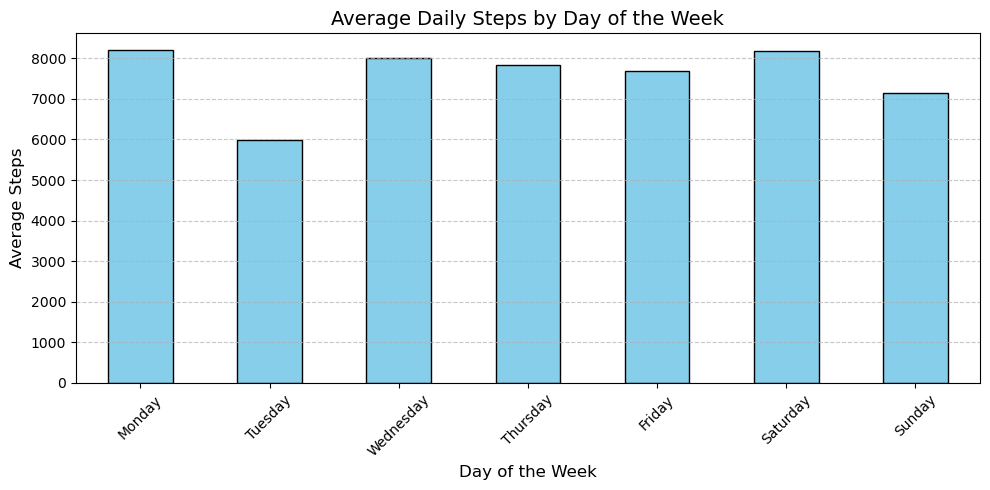

In [8]:
# Group data by DayOfWeek and calculate average steps for each day
days_order    = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_steps = df_clean.groupby('DayOfWeek')['TotalSteps'].mean().reindex(days_order)
 
# Plot the data
plt.figure(figsize=(10, 5))
weekday_steps.plot(kind='bar', color='skyblue', edgecolor='black')
 
plt.title('Average Daily Steps by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
# Calculate the average minutes for each activity intensity
avg_very_active    = df_clean['VeryActiveMinutes'].mean()
avg_fairly_active  = df_clean['FairlyActiveMinutes'].mean()
avg_lightly_active = df_clean['LightlyActiveMinutes'].mean()
avg_sedentary      = df_clean['SedentaryMinutes'].mean()
 
print("--- Average Minutes Per Day Per User ---")
print("Very Active Minutes:", round(avg_very_active, 1))
print("Fairly Active Minutes:", round(avg_fairly_active, 1))
print("Lightly Active Minutes:", round(avg_lightly_active, 1))
print("Sedentary Minutes (Inactivity):", round(avg_sedentary, 1))

--- Average Minutes Per Day Per User ---
Very Active Minutes: 19.1
Fairly Active Minutes: 13.4
Lightly Active Minutes: 196.3
Sedentary Minutes (Inactivity): 942.2


In [10]:
# Convert sedentary minutes to hours
sedentary_hours = avg_sedentary / 60
print("Average sedentary time per day:", round(sedentary_hours, 1), "hours")

Average sedentary time per day: 15.7 hours


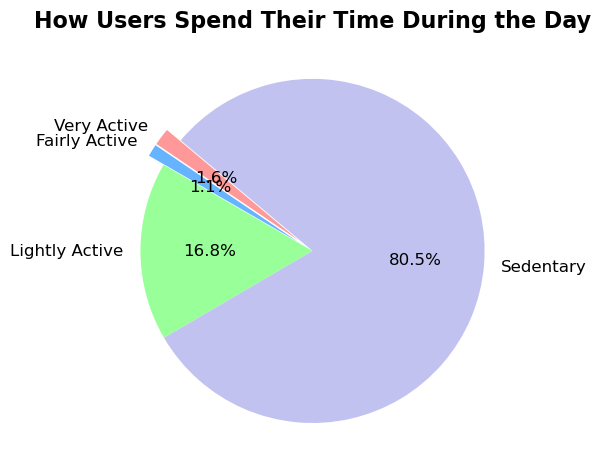

In [11]:
# Using calculated variables instead of hardcoded numbers — chart updates
# automatically if the data changes.
activities = ['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary']
minutes    = [avg_very_active, avg_fairly_active, avg_lightly_active, avg_sedentary]
colors     = ['#ff9999', '#66b3ff', '#99ff99', '#c2c2f0']
explode    = (0.1, 0.1, 0, 0)

plt.figure(figsize=(6, 6))
plt.pie(minutes, explode=explode, labels=activities, colors=colors,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})

plt.title('How Users Spend Their Time During the Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_chart_activity.png', dpi=150, bbox_inches='tight')
plt.show()

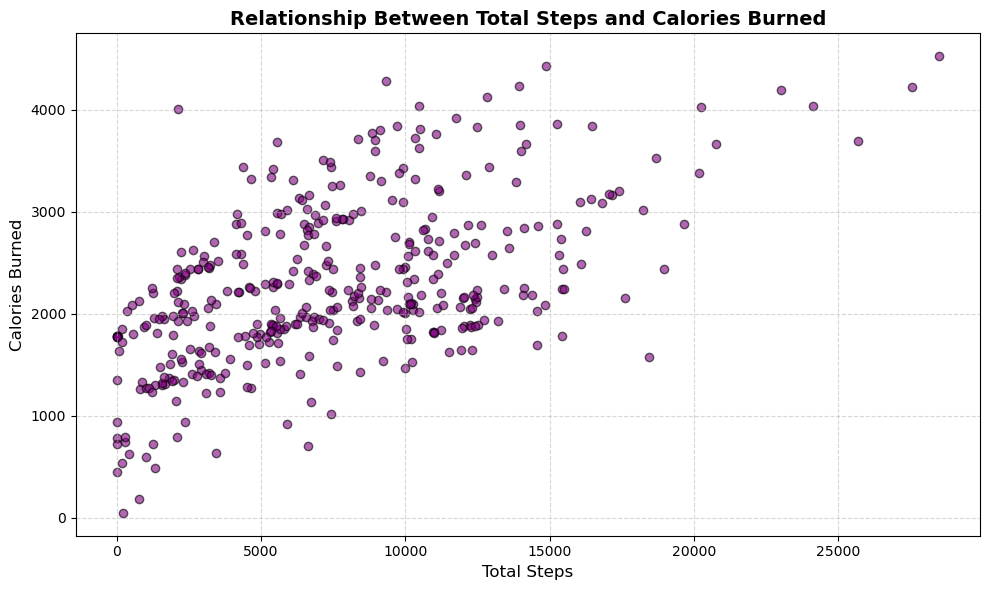

In [12]:
# Create a scatter plot to analyze the relationship between Steps and Calories
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['TotalSteps'], df_clean['Calories'],
            alpha=0.6, color='purple', edgecolor='black')
 
plt.title('Relationship Between Total Steps and Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Calories Burned', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
 
# Points near the Y-axis (~1500-2000 kcal at low steps) represent
# basal metabolic rate — calories burned at rest.

In [13]:
# Save the cleaned data to a new CSV file
df_clean.to_csv('dailyActivity_cleaned.csv', index=False)
print("Cleaned dataset successfully saved to your folder!")

Cleaned dataset successfully saved to your folder!


In [14]:
# Load the dataset — single load, reused throughout Part 2
# value column: 1 = asleep, 2 = restless, 3 = awake
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])
 
print("--- First 5 rows of the dataset ---")
print(df.head())
 
print("\n--- Dataset Info ---")
df.info()
 
print("\n--- Column Names ---")
print(df.columns.tolist())

--- First 5 rows of the dataset ---
           Id                date  value        logId
0  1503960366 2016-03-13 02:39:00      1  11114919637
1  1503960366 2016-03-13 02:40:00      1  11114919637
2  1503960366 2016-03-13 02:41:00      1  11114919637
3  1503960366 2016-03-13 02:42:00      1  11114919637
4  1503960366 2016-03-13 02:43:00      1  11114919637

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198559 entries, 0 to 198558
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Id      198559 non-null  int64         
 1   date    198559 non-null  datetime64[ns]
 2   value   198559 non-null  int64         
 3   logId   198559 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 6.1 MB

--- Column Names ---
['Id', 'date', 'value', 'logId']


In [15]:
# 1. Load the dataset
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Convert 'date' column from text to datetime format
df['date'] = pd.to_datetime(df['date'])

# 3. Create new columns for analysis (Date only and Day of Week)
df['sleep_date'] = df['date'].dt.date
df['day_of_week'] = df['date'].dt.day_name()

# 4. Group by logId to see total minutes per sleep session
# Filter only for minutes spent sleeping (value == 1 means asleep)
sleep_sessions = df[df['value'] == 1].groupby('logId').agg(
    total_minutes=('value', 'count'),
    sleep_start=('date', 'min'),
    sleep_end=('date', 'max')
).reset_index()

# 5. Calculate total hours for convenience
sleep_sessions['total_hours'] = round(sleep_sessions['total_minutes'] / 60, 2)

# 6. Display the results
print("--- Sleep Sessions Summary ---")
print(sleep_sessions.head())

--- Sleep Sessions Summary ---
         logId  total_minutes         sleep_start           sleep_end  \
0  11103653021            415 2016-03-11 23:31:00 2016-03-12 06:38:00   
1  11103710844            352 2016-03-11 22:42:00 2016-03-12 04:39:00   
2  11103729104            509 2016-03-11 21:31:00 2016-03-12 06:34:00   
3  11103744323            413 2016-03-11 23:46:00 2016-03-12 06:57:00   
4  11104043433            201 2016-03-12 02:47:00 2016-03-12 06:12:00   

   total_hours  
0         6.92  
1         5.87  
2         8.48  
3         6.88  
4         3.35  


In [16]:
# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Count total minute records per user
print("--- Total Records (Minutes) per User ---")
user_counts = df['Id'].value_counts()
print(user_counts)

# 3. Calculate average sleep hours for each user
# First, group by User and Sleep Session (logId) to get total hours per night
session_sleep = df[df['value'] == 1].groupby(['Id', 'logId']).size().reset_index(name='total_minutes')
session_sleep['total_hours'] = session_sleep['total_minutes'] / 60

# Second, calculate the mean sleep duration for each individual user
print("\n--- Average Sleep Duration per User (Hours) ---")
user_avg_sleep = session_sleep.groupby('Id')['total_hours'].mean().round(2).reset_index()
user_avg_sleep.columns = ['User_ID', 'Average_Sleep_Hours']
display(user_avg_sleep)

--- Total Records (Minutes) per User ---
Id
2026352035    17504
8378563200    15111
6962181067    14903
5553957443    14602
5577150313    13885
2347167796    13484
4702921684    13148
4319703577    12951
6117666160    12925
1927972279    11513
7086361926    10407
1503960366     9629
4445114986     9581
3977333714     6620
4020332650     5752
8792009665     5544
6775888955     5294
1644430081     1922
1844505072     1922
4558609924      656
7007744171      561
8053475328      501
2022484408      144
Name: count, dtype: int64

--- Average Sleep Duration per User (Hours) ---


,User_ID,Average_Sleep_Hours
0,1503960366,5.30
1,1644430081,11.94
2,1844505072,11.98
3,1927972279,4.47
4,2022484408,2.25
5,2026352035,8.48
6,2347167796,7.29
7,3977333714,4.58
8,4020332650,4.56
9,4319703577,7.57


In [17]:
# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Calculate total hours for each unique sleep session per user
sessions = df[df['value'] == 1].groupby(['Id', 'logId']).size().reset_index(name='minutes')
sessions['hours'] = sessions['minutes'] / 60

# 3. Aggregate statistics per user
user_stats = sessions.groupby('Id').agg(
    total_nights_tracked=('logId', 'count'),
    min_sleep_hours=('hours', 'min'),
    max_sleep_hours=('hours', 'max'),
    avg_sleep_hours=('hours', 'mean')
).reset_index()

# 4. Round values for clean formatting
user_stats = user_stats.round(2)

# 5. Sort users by their average sleep time (descending)
user_stats_sorted = user_stats.sort_values(by='avg_sleep_hours', ascending=False)

# 6. Display the final leaderboard
print("--- User Sleep Leaderboard (Sorted by Average Sleep Hours) ---")
print(user_stats_sorted)

--- User Sleep Leaderboard (Sorted by Average Sleep Hours) ---
            Id  total_nights_tracked  min_sleep_hours  max_sleep_hours  \
2   1844505072                     2             8.30            15.67   
1   1644430081                     2             9.90            13.98   
5   2026352035                    32             1.77            10.17   
20  8053475328                     1             8.30             8.30   
9   4319703577                    27             1.52             9.53   
6   2347167796                    28             2.27             8.87   
19  7086361926                    25             1.13            10.17   
17  6962181067                    36             1.03            10.02   
12  4702921684                    32             1.15             9.47   
13  5553957443                    40             0.90            10.93   
0   1503960366                    28             0.93             7.82   
14  5577150313                    44             

In [18]:
# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Calculate session details
sessions = df[df['value'] == 1].groupby(['Id', 'logId']).agg(
    total_minutes=('value', 'count'),
    sleep_start=('date', 'min'),
    sleep_end=('date', 'max')
).reset_index()
sessions['total_hours'] = round(sessions['total_minutes'] / 60, 2)

# 3. Find the shortest sleep sessions (less than 2 hours)
print("--- Shortest Sleep Sessions (Potential Outliers / Naps) ---")
short_sessions = sessions[sessions['total_hours'] < 2.0].sort_values(by='total_hours')
print(short_sessions.head(10))

# 4. Find the longest sleep sessions (more than 10 hours)
print("\n--- Longest Sleep Sessions (Deep Rest) ---")
long_sessions = sessions[sessions['total_hours'] > 10.0].sort_values(by='total_hours', ascending=False)
print(long_sessions.head(10))

--- Shortest Sleep Sessions (Potential Outliers / Naps) ---
             Id        logId  total_minutes         sleep_start  \
381  6117666160  11210710662             51 2016-03-24 14:56:00   
294  5553957443  11260198135             54 2016-03-27 15:10:00   
14   1503960366  11232921147             56 2016-03-26 23:46:00   
459  7007744171  11290942631             56 2016-04-02 20:51:00   
457  7007744171  11260808655             57 2016-03-26 14:14:00   
384  6117666160  11243404164             58 2016-03-26 19:39:00   
33   1927972279  11109334617             59 2016-03-12 19:44:00   
338  5577150313  11281222431             60 2016-03-28 21:07:00   
283  5553957443  11156470370             60 2016-03-17 18:55:00   
53   1927972279  11215825759             60 2016-03-25 07:56:00   

              sleep_end  total_hours  
381 2016-03-24 15:55:00         0.85  
294 2016-03-27 16:07:00         0.90  
14  2016-03-27 00:46:00         0.93  
459 2016-04-02 21:54:00         0.93  
457 201

In [19]:
# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Find the logId of the absolute longest sleep session
# Filter value == 1 to find the longest actual sleep, not total tracked time
sessions = df[df['value'] == 1].groupby('logId').size().reset_index(name='total_minutes')
longest_log_id = sessions.sort_values(by='total_minutes', ascending=False).iloc[0]['logId']

# 3. Filter the original data to look ONLY at this specific session
longest_session_data = df[df['logId'] == longest_log_id]

# 4. Count sleep statuses during this specific session
print(f"--- Analysis of the Longest Session (logId: {longest_log_id}) ---")
print(longest_session_data['value'].value_counts())
# value 1 = asleep | value 2 = restless | value 3 = awake

--- Analysis of the Longest Session (logId: 11307034191) ---
value
1    940
3     21
Name: count, dtype: int64


In [20]:
# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Count total minutes and deep sleep minutes per user
user_sleep_efficiency = df.groupby('Id').agg(
    total_minutes=('value', 'count'),
    deep_sleep_minutes=('value', lambda x: (x == 1).sum())
).reset_index()

# 3. Calculate efficiency percentage
user_sleep_efficiency['sleep_efficiency_pct'] = round(
    (user_sleep_efficiency['deep_sleep_minutes'] / user_sleep_efficiency['total_minutes']) * 100, 2
)

# 4. Sort by efficiency (highest to lowest) and clean index
user_sleep_efficiency = user_sleep_efficiency.sort_values(
    by='sleep_efficiency_pct', ascending=False).reset_index(drop=True)

print("--- User Sleep Efficiency (%) ---")
print(user_sleep_efficiency)

--- User Sleep Efficiency (%) ---
            Id  total_minutes  deep_sleep_minutes  sleep_efficiency_pct
0   8053475328            501                 498                 99.40
1   4558609924            656                 646                 98.48
2   7086361926          10407               10018                 96.26
3   6962181067          14903               14298                 95.94
4   1927972279          11513               10989                 95.45
5   4020332650           5752                5466                 95.03
6   4319703577          12951               12257                 94.64
7   6117666160          12925               12226                 94.59
8   5577150313          13885               13119                 94.48
9   8792009665           5544                5225                 94.25
10  4702921684          13148               12385                 94.20
11  2022484408            144                 135                 93.75
12  4445114986           9581 

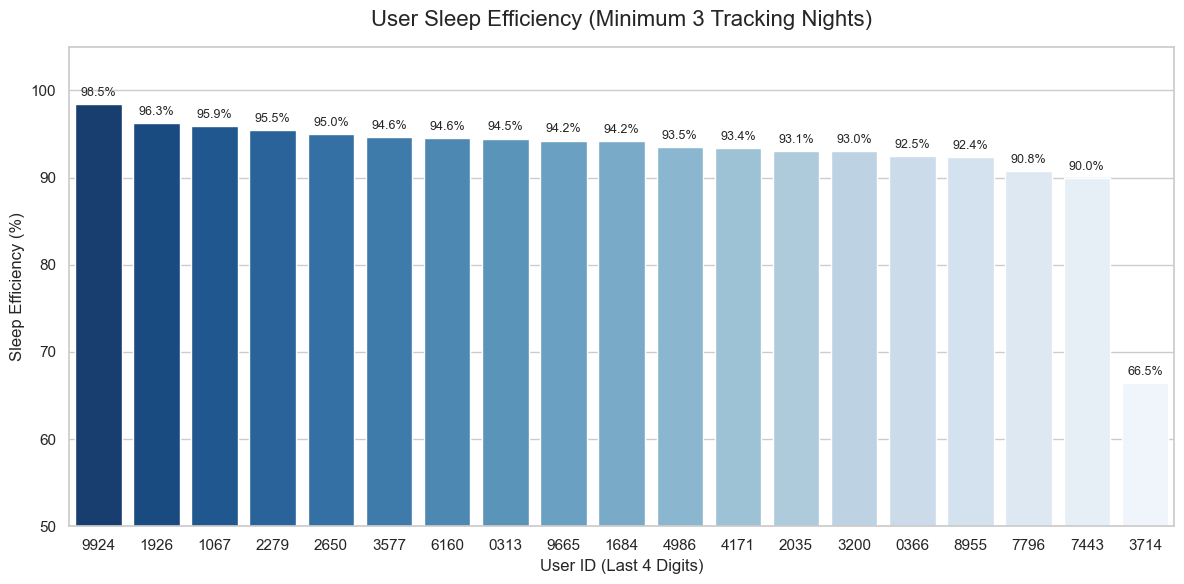

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Calculate user statistics: total sleep minutes, deep sleep minutes, and unique nights
user_stats = df.groupby('Id').agg(
    total_min=('value', 'count'),
    deep_min=('value', lambda x: (x == 1).sum()),
    total_nights=('logId', 'nunique')
).reset_index()

# 3. Calculate sleep efficiency percentage
user_stats['efficiency_pct'] = round((user_stats['deep_min'] / user_stats['total_min']) * 100, 2)

# 4. FILTERING: Keep only users with at least 3 tracked nights
# This filters out anomalies and ensures more reliable data
filtered_stats = user_stats[user_stats['total_nights'] >= 3].sort_values(
    by='efficiency_pct', ascending=False).reset_index(drop=True)

# Truncate User IDs to the last 4 digits for a cleaner chart layout
filtered_stats['Short_ID'] = filtered_stats['Id'].astype(str).str[-4:]

# 5. VISUALIZATION
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot with a beautiful color gradient
ax = sns.barplot(
    x='Short_ID',
    y='efficiency_pct',
    data=filtered_stats,
    palette='Blues_r',
    hue='Short_ID',
    legend=False
)

plt.title('User Sleep Efficiency (Minimum 3 Tracking Nights)', fontsize=16, pad=15)
plt.xlabel('User ID (Last 4 Digits)', fontsize=12)
plt.ylabel('Sleep Efficiency (%)', fontsize=12)
plt.ylim(50, 105)

# Add text percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()